<a href="https://colab.research.google.com/github/menahilbak502/Employee-Attrition-Analysis/blob/main/Employee_Attrition_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving HR_Analytics.csv.csv to HR_Analytics.csv.csv
Shape: (1470, 35)

Column dtypes:
 Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
Sta

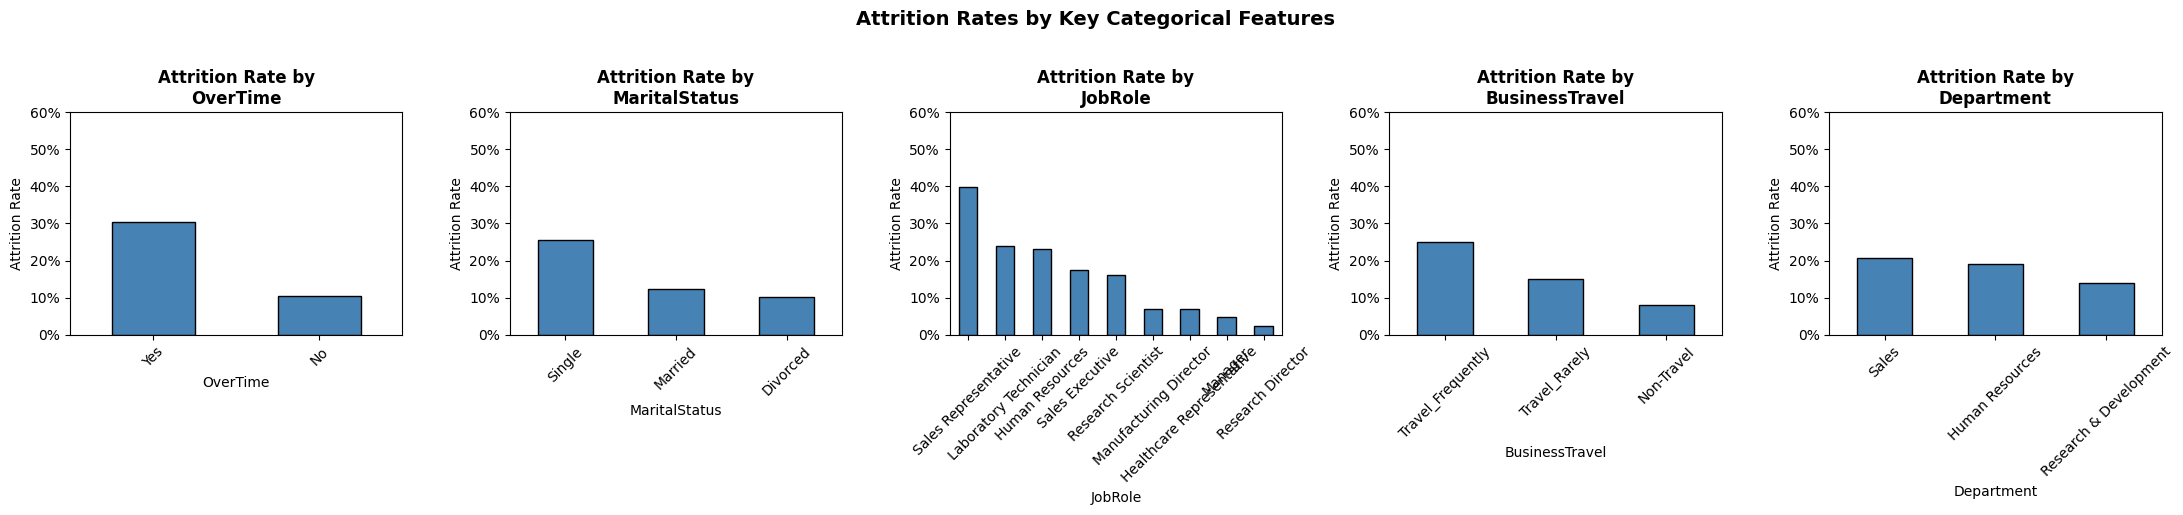

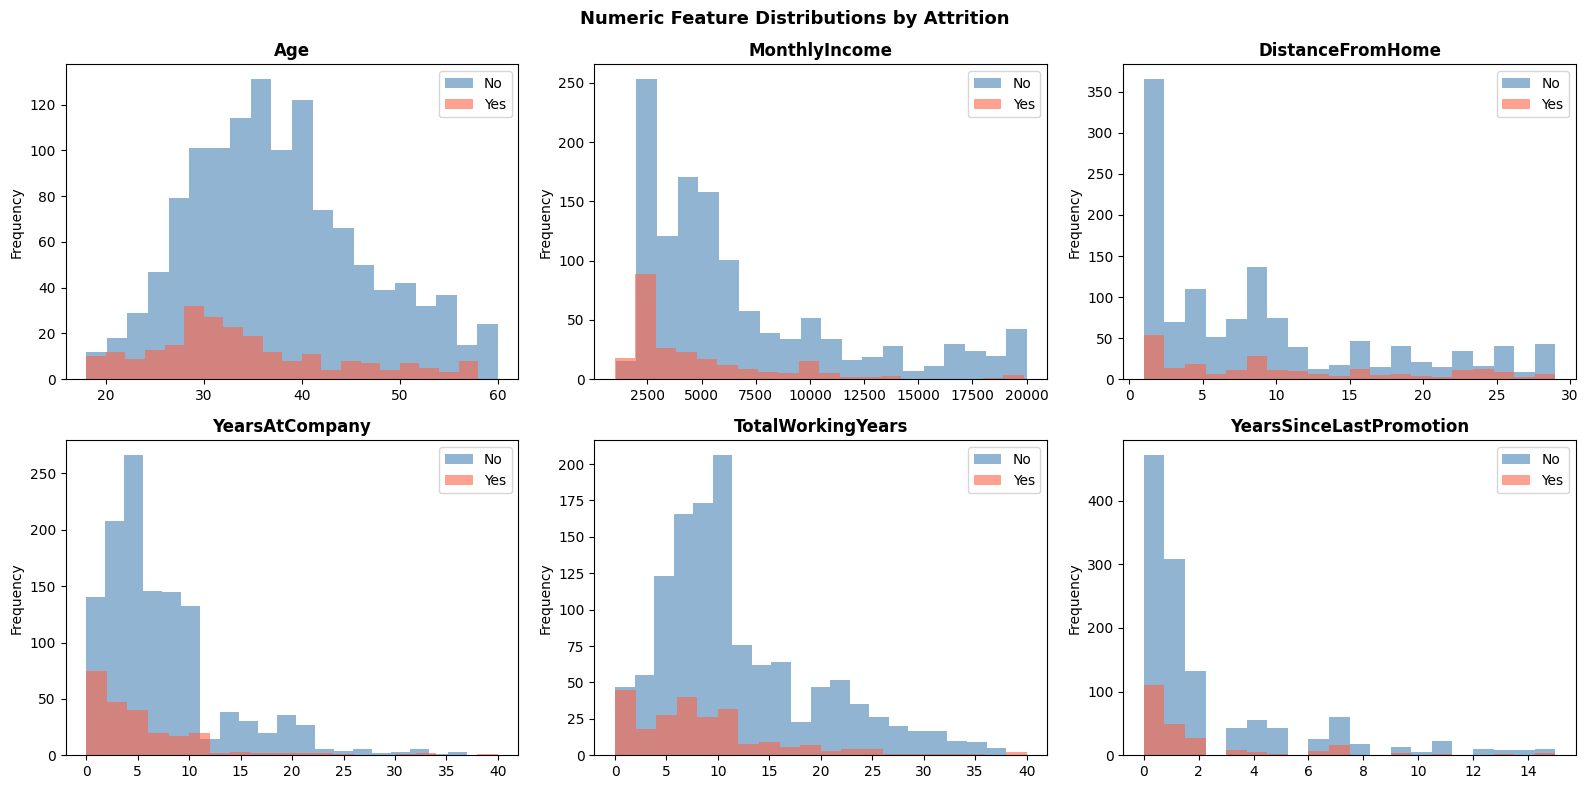

Encoding: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Features: 44, Samples: 1470
Class balance: {0: 1233, 1: 237}

Train: 1029 rows | Test: 441 rows
% Attrition in train: 16.13%
% Attrition in test:  16.10%

✅ Block 1 complete — data ready for modeling.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)


from google.colab import files
uploaded = files.upload()  # upload HR_Analytics_csv.csv
df = pd.read_csv(list(uploaded.keys())[0])

print("Shape:", df.shape)
df.head()

print("\nColumn dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nAttrition distribution:\n", df['Attrition'].value_counts())
print("\nAttrition rate:", round(df['Attrition'].value_counts(normalize=True)['Yes'], 3))

cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=cols_to_drop, inplace=True)
print("Dropped:", cols_to_drop)

df['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)

cat_features = ['OverTime', 'MaritalStatus', 'JobRole', 'BusinessTravel', 'Department']
fig, axes = plt.subplots(1, len(cat_features), figsize=(22, 5))
for ax, col in zip(axes, cat_features):
    rates = df.groupby(col)['Attrition_bin'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Attrition Rate by\n{col}', fontweight='bold')
    ax.set_ylabel('Attrition Rate')
    ax.set_ylim(0, 0.6)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Attrition Rates by Key Categorical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

num_features = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'YearsAtCompany',
                'TotalWorkingYears', 'YearsSinceLastPromotion']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, num_features):
    df[df['Attrition_bin'] == 0][col].plot(kind='hist', ax=ax, alpha=0.6, label='No', bins=20, color='steelblue')
    df[df['Attrition_bin'] == 1][col].plot(kind='hist', ax=ax, alpha=0.6, label='Yes', bins=20, color='tomato')
    ax.set_title(col, fontweight='bold')
    ax.legend()
plt.suptitle('Numeric Feature Distributions by Attrition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Attrition')  # keep original label for reference
print("Encoding:", cat_cols)

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_encoded.drop(columns=['Attrition', 'Attrition_bin'])
y = df_encoded['Attrition_bin']

print(f"\nFeatures: {X.shape[1]}, Samples: {X.shape[0]}")
print(f"Class balance: {y.value_counts().to_dict()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"% Attrition in train: {y_train.mean():.2%}")
print(f"% Attrition in test:  {y_test.mean():.2%}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

feature_names = X.columns.tolist()

print("\n✅ Block 1 complete — data ready for modeling.")


Model: Logistic Regression
  Accuracy:  0.880
  Precision: 0.725
  Recall:    0.408
  F1 Score:  0.523
  ROC-AUC:   0.820

Confusion Matrix:


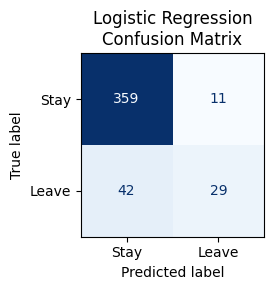


Model: Decision Tree (depth=5)
  Accuracy:  0.832
  Precision: 0.457
  Recall:    0.225
  F1 Score:  0.302
  ROC-AUC:   0.693

Confusion Matrix:


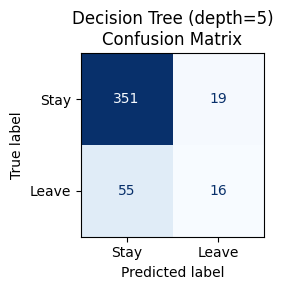


Top Decision Tree Rules:
|--- TotalWorkingYears <= 1.50
|   |--- JobRole_Research Scientist <= 0.50
|   |   |--- Age <= 28.50
|   |   |   |--- DailyRate <= 996.50
|   |   |   |   |--- class: 1
|   |   |   |--- DailyRate >  996.50
|   |   |   |   |--- class: 1
|   |   |--- Age >  28.50
|   |   |   |--- class: 0
|   |--- JobRole_Research Scientist >  0.50
|   |   |--- DistanceFromHome <= 6.00
|   |   |   |--- class: 0
|   |   |--- DistanceFromHome >  6.00
|   |   |   |--- class: 1
|--- TotalWorkingYears >  1.50
|   |--- OverTime_Yes <= 0.50
|   |   |--- WorkLifeBalance <= 1.50
|   |   |   |--- StockOptionLevel <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- StockOptionLevel >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- WorkLifeBalance >  1.50
|   |   |   |--- NumCompaniesWorked <= 4.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- NumCompaniesWorked >  4.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- OverTime_Yes >  0.50
|

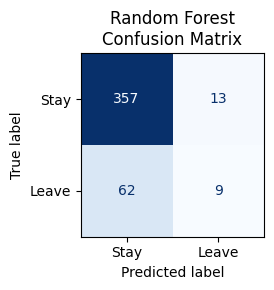


Model: Neural Network (16-8)
  Accuracy:  0.832
  Precision: 0.477
  Recall:    0.437
  F1 Score:  0.456
  ROC-AUC:   0.737

Confusion Matrix:


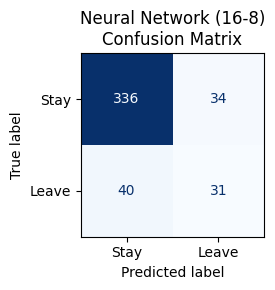


Model: KNN (k=11)
  Accuracy:  0.841
  Precision: 0.556
  Recall:    0.070
  F1 Score:  0.125
  ROC-AUC:   0.686

Confusion Matrix:


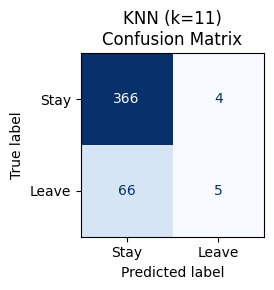


Model: Naive Bayes
  Accuracy:  0.635
  Precision: 0.266
  Recall:    0.718
  F1 Score:  0.388
  ROC-AUC:   0.709

Confusion Matrix:


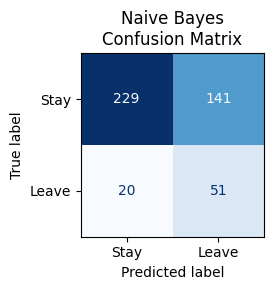


MODEL COMPARISON TABLE
                         Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                               
Logistic Regression         0.880      0.725   0.408  0.523    0.820
Decision Tree (depth=5)     0.832      0.457   0.225  0.302    0.693
Random Forest               0.830      0.409   0.127  0.194    0.774
Neural Network (16-8)       0.832      0.477   0.437  0.456    0.737
KNN (k=11)                  0.841      0.556   0.070  0.125    0.686
Naive Bayes                 0.635      0.266   0.718  0.388    0.709


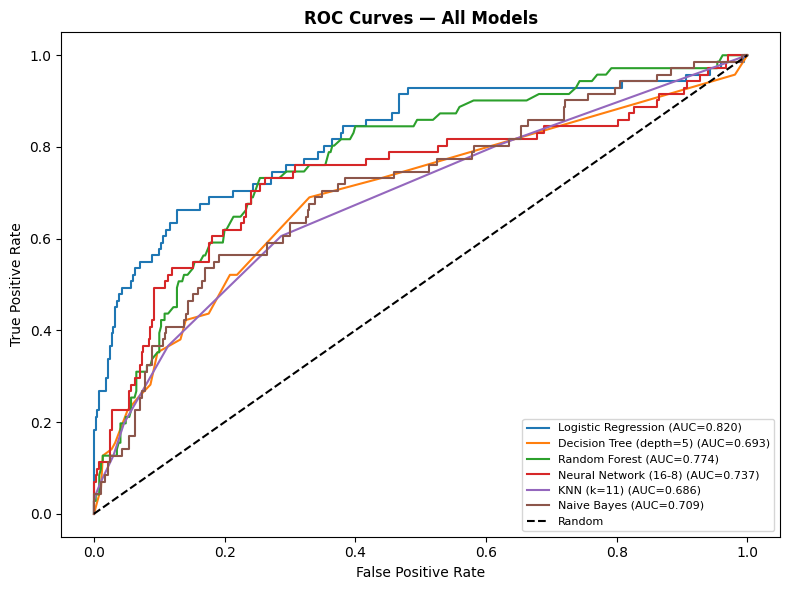

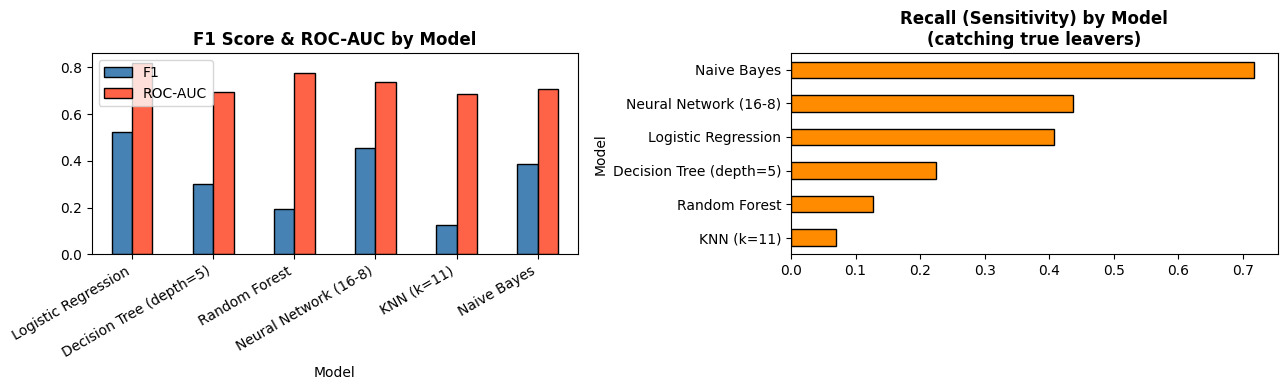


✅ Block 2 complete — models trained and compared.


In [ ]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    """Fits model and returns evaluation metrics dict."""
    Xtr = X_tr if not scaled else X_train_sc
    Xte = X_te if not scaled else X_test_sc

    model.fit(Xtr, y_tr)
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1] if hasattr(model, 'predict_proba') else None

    acc   = accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, zero_division=0)
    rec   = recall_score(y_te, y_pred, zero_division=0)
    f1    = f1_score(y_te, y_pred, zero_division=0)
    auc   = roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1 Score:  {f1:.3f}")
    print(f"  ROC-AUC:   {auc:.3f}")
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Leave'])
    fig, ax = plt.subplots(figsize=(4, 3))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nConfusion Matrix')
    plt.tight_layout()
    plt.show()

    return {
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'ROC-AUC': auc,
        'fitted_model': model, 'y_proba': y_proba
    }

results = []

lr = LogisticRegression(max_iter=1000, random_state=42)
r = evaluate_model('Logistic Regression', lr, X_train_sc, X_test_sc, y_train, y_test, scaled=True)
results.append(r)

dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
r = evaluate_model('Decision Tree (depth=5)', dt, X_train, X_test, y_train, y_test)
results.append(r)

print("\nTop Decision Tree Rules:")
print(export_text(dt, feature_names=feature_names, max_depth=3))

rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
r = evaluate_model('Random Forest', rf, X_train, X_test, y_train, y_test)
results.append(r)

nn = MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu',
                   solver='adam', max_iter=500, random_state=42)
r = evaluate_model('Neural Network (16-8)', nn, X_train_sc, X_test_sc, y_train, y_test, scaled=True)
results.append(r)

knn = KNeighborsClassifier(n_neighbors=11)
r = evaluate_model('KNN (k=11)', knn, X_train_sc, X_test_sc, y_train, y_test, scaled=True)
results.append(r)

nb = GaussianNB()
r = evaluate_model('Naive Bayes', nb, X_train_sc, X_test_sc, y_train, y_test, scaled=True)
results.append(r)

metrics_df = pd.DataFrame([{k: v for k, v in r.items()
                             if k not in ['fitted_model', 'y_proba']} for r in results])
metrics_df = metrics_df.set_index('Model').round(3)
print("\n" + "="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
print(metrics_df.to_string())

fig, ax = plt.subplots(figsize=(8, 6))
for r in results:
    if r['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
        ax.plot(fpr, tpr, label=f"{r['Model']} (AUC={r['ROC-AUC']:.3f})")
ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
metrics_df[['F1', 'ROC-AUC']].plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('F1 Score & ROC-AUC by Model', fontweight='bold')
axes[0].set_xticklabels(metrics_df.index, rotation=30, ha='right')
axes[0].legend()
metrics_df['Recall'].sort_values().plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Recall (Sensitivity) by Model\n(catching true leavers)', fontweight='bold')
plt.tight_layout()
plt.show()

best_rf  = rf
best_lr  = lr

print("\n✅ Block 2 complete — models trained and compared.")

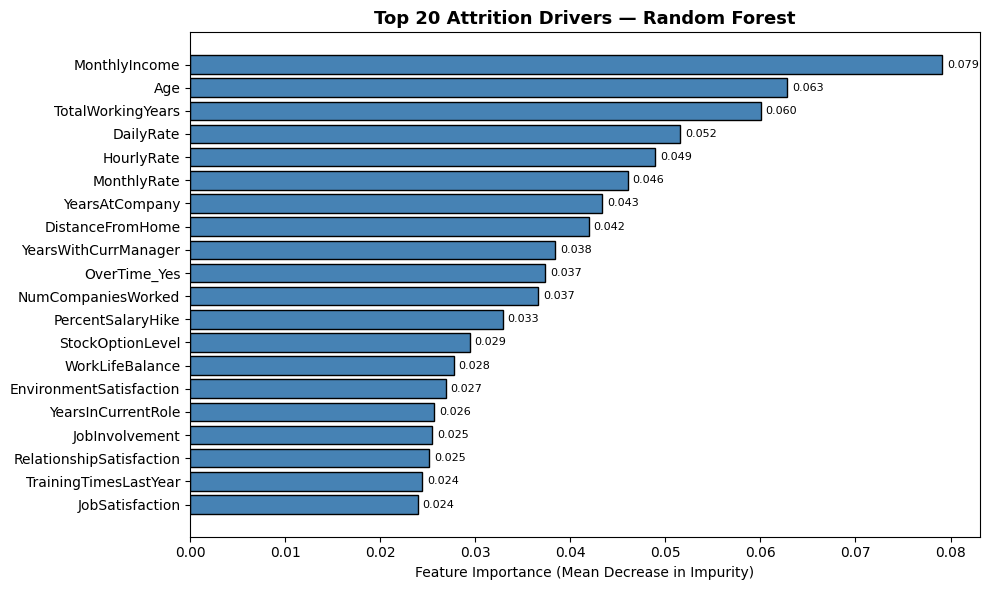

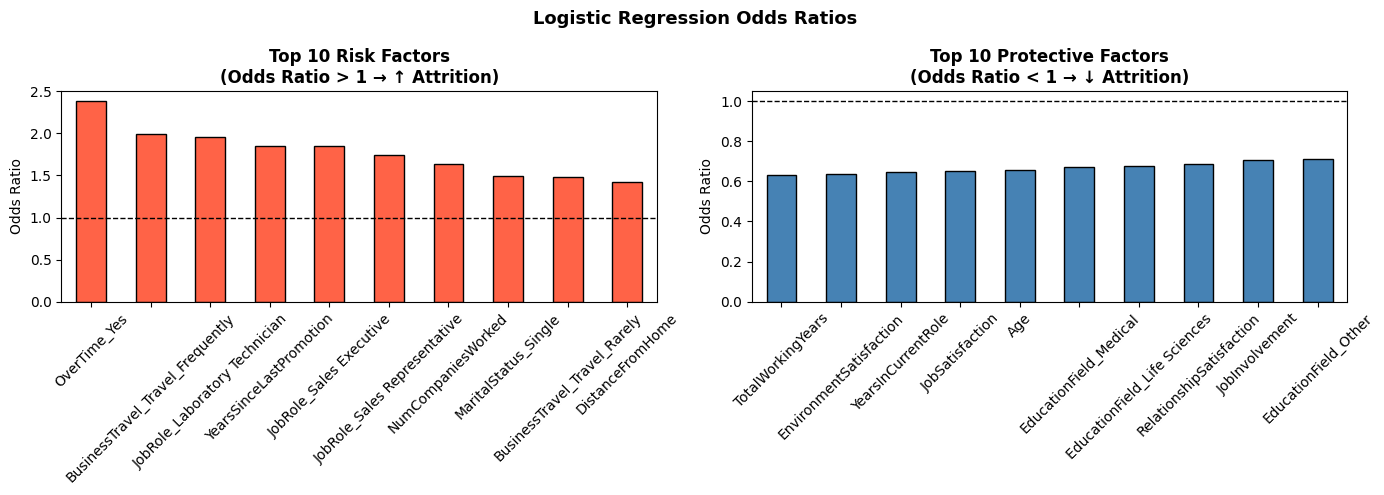

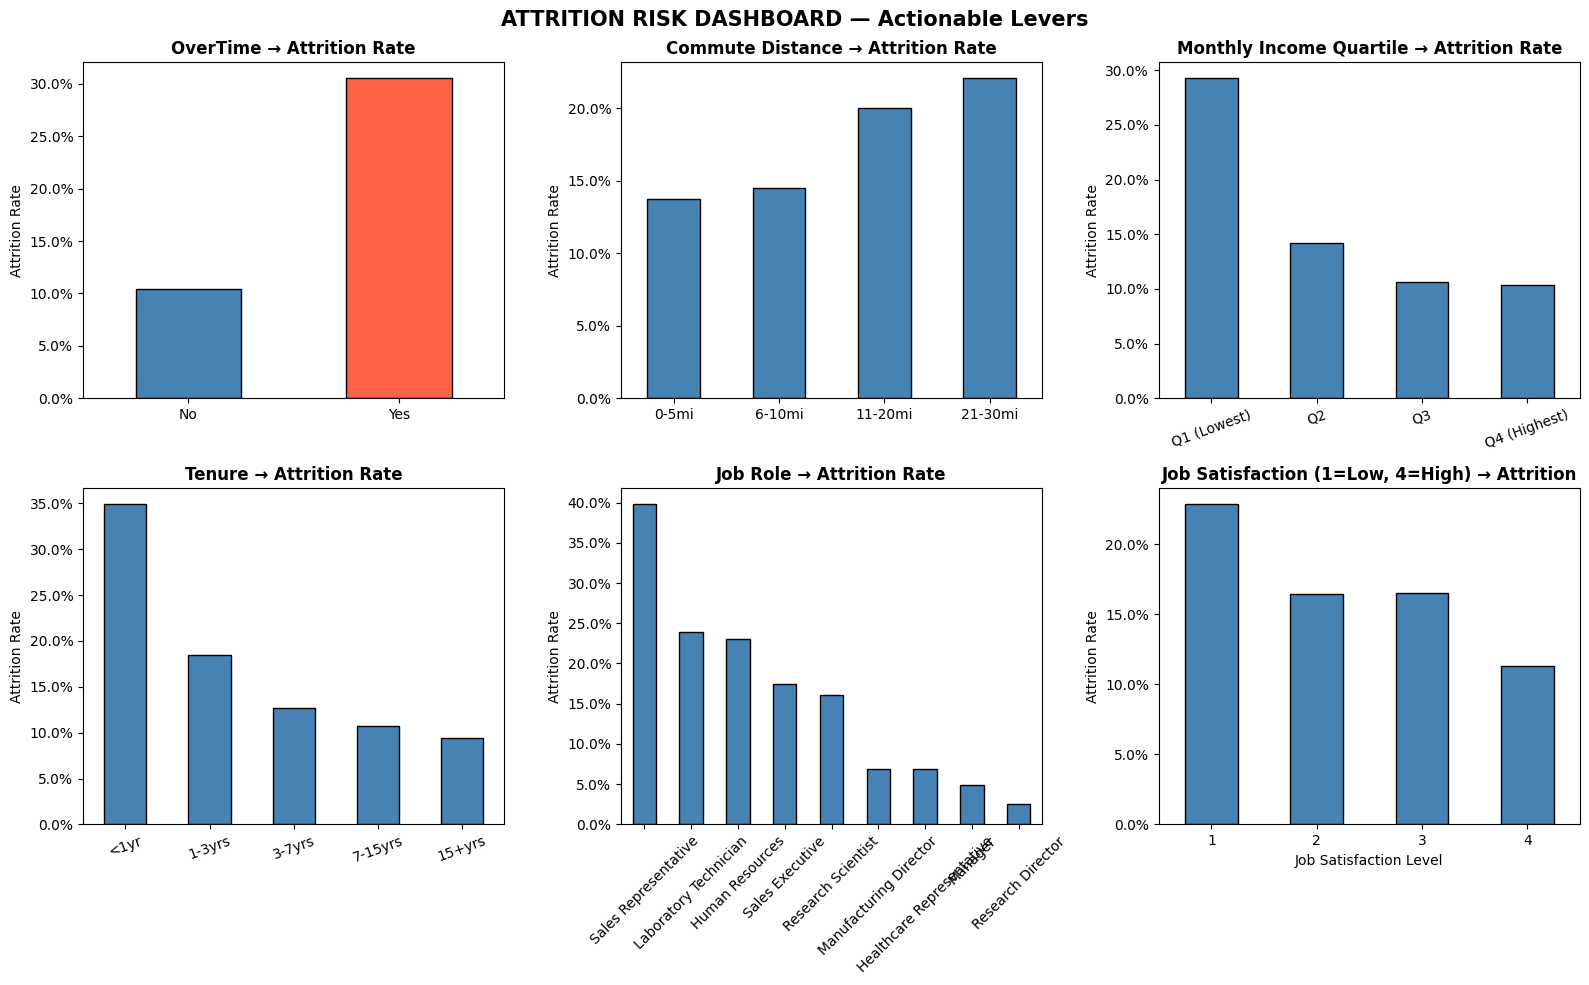


── Risk Tier Distribution ──
Risk_Tier
Low         1158
Critical     171
Medium       115
High          24
Name: count, dtype: int64

── Average Risk Score by Job Role ──
JobRole
Sales Representative         0.388
Laboratory Technician        0.240
Human Resources              0.215
Sales Executive              0.173
Research Scientist           0.164
Manager                      0.081
Healthcare Representative    0.077
Manufacturing Director       0.076
Research Director            0.060


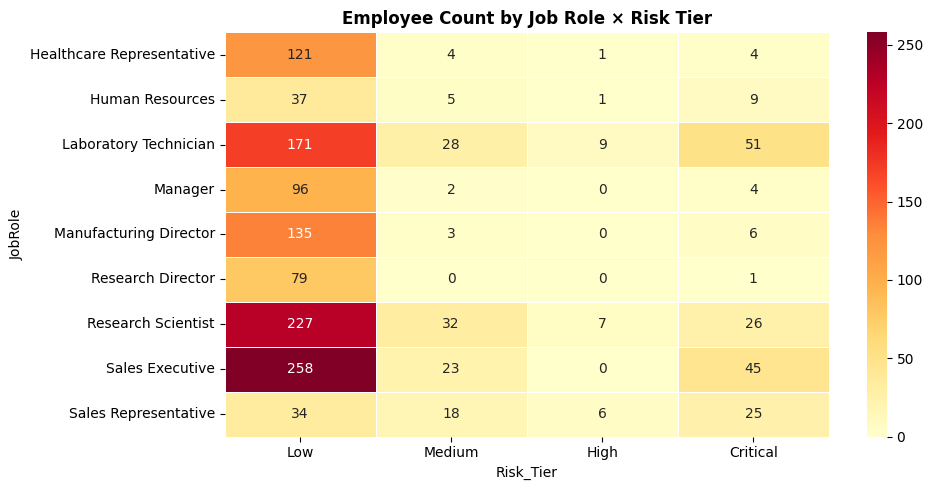


✅ Block 3 complete — Risk Dashboard rendered.


In [ ]:
importances = best_rf.feature_importances_
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_imp = df_imp.sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_imp['Feature'][::-1], df_imp['Importance'][::-1],
               color='steelblue', edgecolor='black')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Top 20 Attrition Drivers — Random Forest', fontweight='bold', fontsize=13)
for bar in bars:
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

lr_coefs = pd.Series(best_lr.coef_[0], index=feature_names)
odds_ratios = np.exp(lr_coefs).sort_values(ascending=False)
top_risk    = odds_ratios.head(10)
top_protect = odds_ratios.tail(10)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_risk.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('Top 10 Risk Factors\n(Odds Ratio > 1 → ↑ Attrition)', fontweight='bold')
axes[0].axhline(1, color='black', linestyle='--', linewidth=1)
axes[0].set_ylabel('Odds Ratio')
axes[0].tick_params(axis='x', rotation=45)

top_protect.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Top 10 Protective Factors\n(Odds Ratio < 1 → ↓ Attrition)', fontweight='bold')
axes[1].axhline(1, color='black', linestyle='--', linewidth=1)
axes[1].set_ylabel('Odds Ratio')
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle('Logistic Regression Odds Ratios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ot = df.groupby('OverTime')['Attrition_bin'].mean()
ot.plot(kind='bar', ax=axes[0,0], color=['steelblue','tomato'], edgecolor='black')
axes[0,0].set_title('OverTime → Attrition Rate', fontweight='bold')
axes[0,0].set_ylabel('Attrition Rate')
axes[0,0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].set_xlabel('')

df['Distance_bucket'] = pd.cut(df['DistanceFromHome'],
                                bins=[0, 5, 10, 20, 30],
                                labels=['0-5mi', '6-10mi', '11-20mi', '21-30mi'])
dist = df.groupby('Distance_bucket')['Attrition_bin'].mean()
dist.plot(kind='bar', ax=axes[0,1], color='steelblue', edgecolor='black')
axes[0,1].set_title('Commute Distance → Attrition Rate', fontweight='bold')
axes[0,1].set_ylabel('Attrition Rate')
axes[0,1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].set_xlabel('')

df['Income_quartile'] = pd.qcut(df['MonthlyIncome'], q=4,
                                  labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])
inc = df.groupby('Income_quartile')['Attrition_bin'].mean()
inc.plot(kind='bar', ax=axes[0,2], color='steelblue', edgecolor='black')
axes[0,2].set_title('Monthly Income Quartile → Attrition Rate', fontweight='bold')
axes[0,2].set_ylabel('Attrition Rate')
axes[0,2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0,2].tick_params(axis='x', rotation=20)
axes[0,2].set_xlabel('')

df['Tenure_bucket'] = pd.cut(df['YearsAtCompany'],
                              bins=[-1, 1, 3, 7, 15, 40],
                              labels=['<1yr', '1-3yrs', '3-7yrs', '7-15yrs', '15+yrs'])
ten = df.groupby('Tenure_bucket')['Attrition_bin'].mean()
ten.plot(kind='bar', ax=axes[1,0], color='steelblue', edgecolor='black')
axes[1,0].set_title('Tenure → Attrition Rate', fontweight='bold')
axes[1,0].set_ylabel('Attrition Rate')
axes[1,0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1,0].tick_params(axis='x', rotation=20)
axes[1,0].set_xlabel('')

jr = df.groupby('JobRole')['Attrition_bin'].mean().sort_values(ascending=False)
jr.plot(kind='bar', ax=axes[1,1], color='steelblue', edgecolor='black')
axes[1,1].set_title('Job Role → Attrition Rate', fontweight='bold')
axes[1,1].set_ylabel('Attrition Rate')
axes[1,1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_xlabel('')

js = df.groupby('JobSatisfaction')['Attrition_bin'].mean()
js.plot(kind='bar', ax=axes[1,2], color='steelblue', edgecolor='black')
axes[1,2].set_title('Job Satisfaction (1=Low, 4=High) → Attrition', fontweight='bold')
axes[1,2].set_ylabel('Attrition Rate')
axes[1,2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1,2].tick_params(axis='x', rotation=0)
axes[1,2].set_xlabel('Job Satisfaction Level')

plt.suptitle('ATTRITION RISK DASHBOARD — Actionable Levers', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

X_all_sc = scaler.transform(X)
risk_probs = best_rf.predict_proba(X)[:, 1]

df_risk = df[['Age','JobRole','OverTime','MonthlyIncome',
              'YearsAtCompany','DistanceFromHome','Attrition']].copy()
df_risk['Risk_Score'] = risk_probs
df_risk['Risk_Tier'] = pd.cut(risk_probs,
                               bins=[0, 0.2, 0.4, 0.6, 1.0],
                               labels=['Low','Medium','High','Critical'])

print("\n── Risk Tier Distribution ──")
print(df_risk['Risk_Tier'].value_counts())
print("\n── Average Risk Score by Job Role ──")
print(df_risk.groupby('JobRole')['Risk_Score'].mean().sort_values(ascending=False).round(3).to_string())

pivot = df_risk.groupby(['JobRole','Risk_Tier']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Employee Count by Job Role × Risk Tier', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✅ Block 3 complete — Risk Dashboard rendered.")

Average Monthly Income:     $6,503
Average Annual Salary:      $78,035
Replacement Cost per Emp:   $78,035
Intervention Cost per Emp:  $3,902

Cost Matrix:
  TP (correctly flag leaver, intervene):  $-74,133  (net saving)
  FP (wrongly flag stayer, intervene):    $3,902  (wasted cost)
  FN (miss leaver, they leave):           $78,035  (replacement cost)
  TN (correctly ignore stayer):           $0

BUSINESS COST ANALYSIS — Test Set

Logistic Regression
  TP=29 | FP=11 | FN=42 | TN=359
  Net Cost to Business: $1,170,528

Decision Tree
  TP=16 | FP=19 | FN=55 | TN=351
  Net Cost to Business: $3,179,933

Random Forest
  TP=9 | FP=13 | FN=62 | TN=357
  Net Cost to Business: $4,221,703

Neural Network
  TP=31 | FP=34 | FN=40 | TN=336
  Net Cost to Business: $955,931

KNN (k=11)
  TP=5 | FP=4 | FN=66 | TN=366
  Net Cost to Business: $4,795,262

Naive Bayes
  TP=51 | FP=141 | FN=20 | TN=229
  Net Cost to Business: $-1,669,953

Baseline (no model, no intervention): $5,540,497


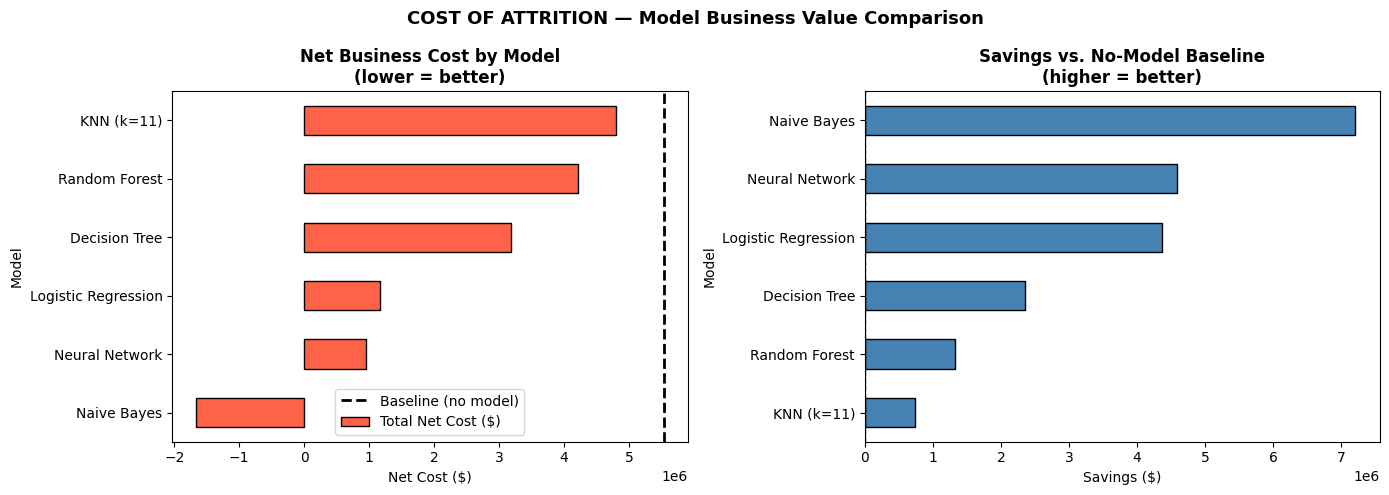


── Threshold Optimization (Logistic Regression) ──
Optimal probability threshold: 0.10
Net cost at optimal threshold: $-2,235,708
Savings over default (0.5):    $3,406,235


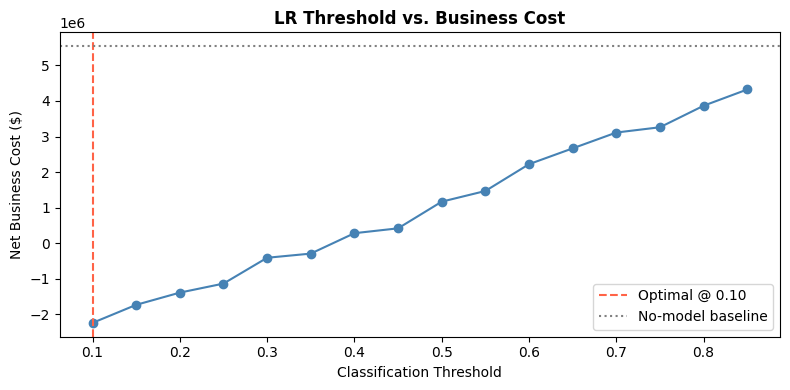


✅ Block 4 complete — Business cost model done.


In [ ]:
# Attrition Cost Assumptions
# Based on industry benchmarks (SHRM, Gallup):
# Replacing an employee costs ~50%-200% of annual salary
# We use 100% of annual salary as a conservative estimate
# Recruiting cost: 30% of annual salary
# Training cost:   20% of annual salary
# Coverage/productivity loss: 50% of annual salary
# Total: 100% annual salary

MONTHLY_AVG_SALARY   = df['MonthlyIncome'].mean()
ANNUAL_AVG_SALARY    = MONTHLY_AVG_SALARY * 12
REPLACE_COST_RATIO   = 1.0   # 100% of annual salary
REPLACE_COST_PER_EMP = ANNUAL_AVG_SALARY * REPLACE_COST_RATIO

# Cost to intervene (retention program, raise, etc.)
# Estimate: ~5% of annual salary per targeted employee
INTERVENTION_COST    = ANNUAL_AVG_SALARY * 0.05

print(f"Average Monthly Income:     ${MONTHLY_AVG_SALARY:,.0f}")
print(f"Average Annual Salary:      ${ANNUAL_AVG_SALARY:,.0f}")
print(f"Replacement Cost per Emp:   ${REPLACE_COST_PER_EMP:,.0f}")
print(f"Intervention Cost per Emp:  ${INTERVENTION_COST:,.0f}")

# ── Business Cost Matrix per Prediction Outcome ───────────
# True Positive  (TP): Correctly flagged leaver → intervene → save replacement cost, pay intervention
# False Positive (FP): Wrongly flagged stayer   → pay intervention, no benefit
# False Negative (FN): Missed leaver            → pay full replacement cost
# True Negative  (TN): Correctly identified stayer → no cost

COST_TP = INTERVENTION_COST - REPLACE_COST_PER_EMP  # Net saving (negative = savings)
COST_FP = INTERVENTION_COST                           # Wasted spend
COST_FN = REPLACE_COST_PER_EMP                        # Full replacement cost
COST_TN = 0

print(f"\nCost Matrix:")
print(f"  TP (correctly flag leaver, intervene):  ${COST_TP:,.0f}  (net saving)")
print(f"  FP (wrongly flag stayer, intervene):    ${COST_FP:,.0f}  (wasted cost)")
print(f"  FN (miss leaver, they leave):           ${COST_FN:,.0f}  (replacement cost)")
print(f"  TN (correctly ignore stayer):           ${COST_TN:,.0f}")

def business_cost(y_true, y_pred, cost_tp, cost_fp, cost_fn, cost_tn):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = (tp * cost_tp) + (fp * cost_fp) + (fn * cost_fn) + (tn * cost_tn)
    return total_cost, tn, fp, fn, tp

print("\n" + "="*65)
print("BUSINESS COST ANALYSIS — Test Set")
print("="*65)

model_dict = {
    'Logistic Regression': (best_lr,  X_test_sc),
    'Decision Tree':       (dt,        X_test),
    'Random Forest':       (best_rf,   X_test),
    'Neural Network':      (nn,        X_test_sc),
    'KNN (k=11)':          (knn,       X_test_sc),
    'Naive Bayes':         (nb,        X_test_sc),
}

business_results = []
for name, (model, X_te) in model_dict.items():
    y_pred = model.predict(X_te)
    total, tn, fp, fn, tp = business_cost(y_test, y_pred,
                                           COST_TP, COST_FP, COST_FN, COST_TN)
    business_results.append({
        'Model': name,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Total Net Cost ($)': total
    })
    print(f"\n{name}")
    print(f"  TP={tp} | FP={fp} | FN={fn} | TN={tn}")
    print(f"  Net Cost to Business: ${total:,.0f}")

baseline_cost = y_test.sum() * REPLACE_COST_PER_EMP
print(f"\nBaseline (no model, no intervention): ${baseline_cost:,.0f}")

biz_df = pd.DataFrame(business_results).set_index('Model')
biz_df['Savings vs Baseline ($)'] = baseline_cost - biz_df['Total Net Cost ($)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

biz_df['Total Net Cost ($)'].sort_values().plot(kind='barh', ax=axes[0],
                                                 color='tomato', edgecolor='black')
axes[0].axvline(baseline_cost, color='black', linestyle='--', linewidth=2, label='Baseline (no model)')
axes[0].set_title('Net Business Cost by Model\n(lower = better)', fontweight='bold')
axes[0].set_xlabel('Net Cost ($)')
axes[0].legend()

biz_df['Savings vs Baseline ($)'].sort_values().plot(kind='barh', ax=axes[1],
                                                      color='steelblue', edgecolor='black')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Savings vs. No-Model Baseline\n(higher = better)', fontweight='bold')
axes[1].set_xlabel('Savings ($)')

plt.suptitle('COST OF ATTRITION — Model Business Value Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n── Threshold Optimization (Logistic Regression) ──")
y_proba_lr = best_lr.predict_proba(X_test_sc)[:, 1]
thresholds  = np.arange(0.1, 0.9, 0.05)
costs_by_thresh = []
for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    cost, *_ = business_cost(y_test, y_pred_t, COST_TP, COST_FP, COST_FN, COST_TN)
    costs_by_thresh.append({'Threshold': t, 'Net Cost': cost})

thresh_df = pd.DataFrame(costs_by_thresh)
best_t = thresh_df.loc[thresh_df['Net Cost'].idxmin()]
print(f"Optimal probability threshold: {best_t['Threshold']:.2f}")
print(f"Net cost at optimal threshold: ${best_t['Net Cost']:,.0f}")
print(f"Savings over default (0.5):    ${business_cost(y_test, (y_proba_lr>=0.5).astype(int), COST_TP, COST_FP, COST_FN, COST_TN)[0] - best_t['Net Cost']:,.0f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresh_df['Threshold'], thresh_df['Net Cost'], 'o-', color='steelblue')
ax.axvline(best_t['Threshold'], color='tomato', linestyle='--',
           label=f"Optimal @ {best_t['Threshold']:.2f}")
ax.axhline(baseline_cost, color='gray', linestyle=':', label='No-model baseline')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Net Business Cost ($)')
ax.set_title('LR Threshold vs. Business Cost', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\n✅ Block 4 complete — Business cost model done.")

Role Group distribution:
 RoleGroup
Technical     682
Sales         409
Management    327
Admin/HR       52
Name: count, dtype: int64

Attrition rate by group:
RoleGroup
Admin/HR      23.1%
Sales         22.0%
Technical     17.3%
Management     5.2%
Name: Attrition_bin, dtype: object

Role Group: Admin/HR  (n=52, attrition=23.1%)
  Accuracy=0.750 | Recall=0.250 | F1=0.333 | AUC=0.708

Role Group: Management  (n=327, attrition=5.2%)
  Accuracy=0.949 | Recall=0.000 | F1=0.000 | AUC=0.463

Role Group: Sales  (n=409, attrition=22.0%)
  Accuracy=0.805 | Recall=0.185 | F1=0.294 | AUC=0.744

Role Group: Technical  (n=682, attrition=17.3%)
  Accuracy=0.824 | Recall=0.114 | F1=0.182 | AUC=0.709


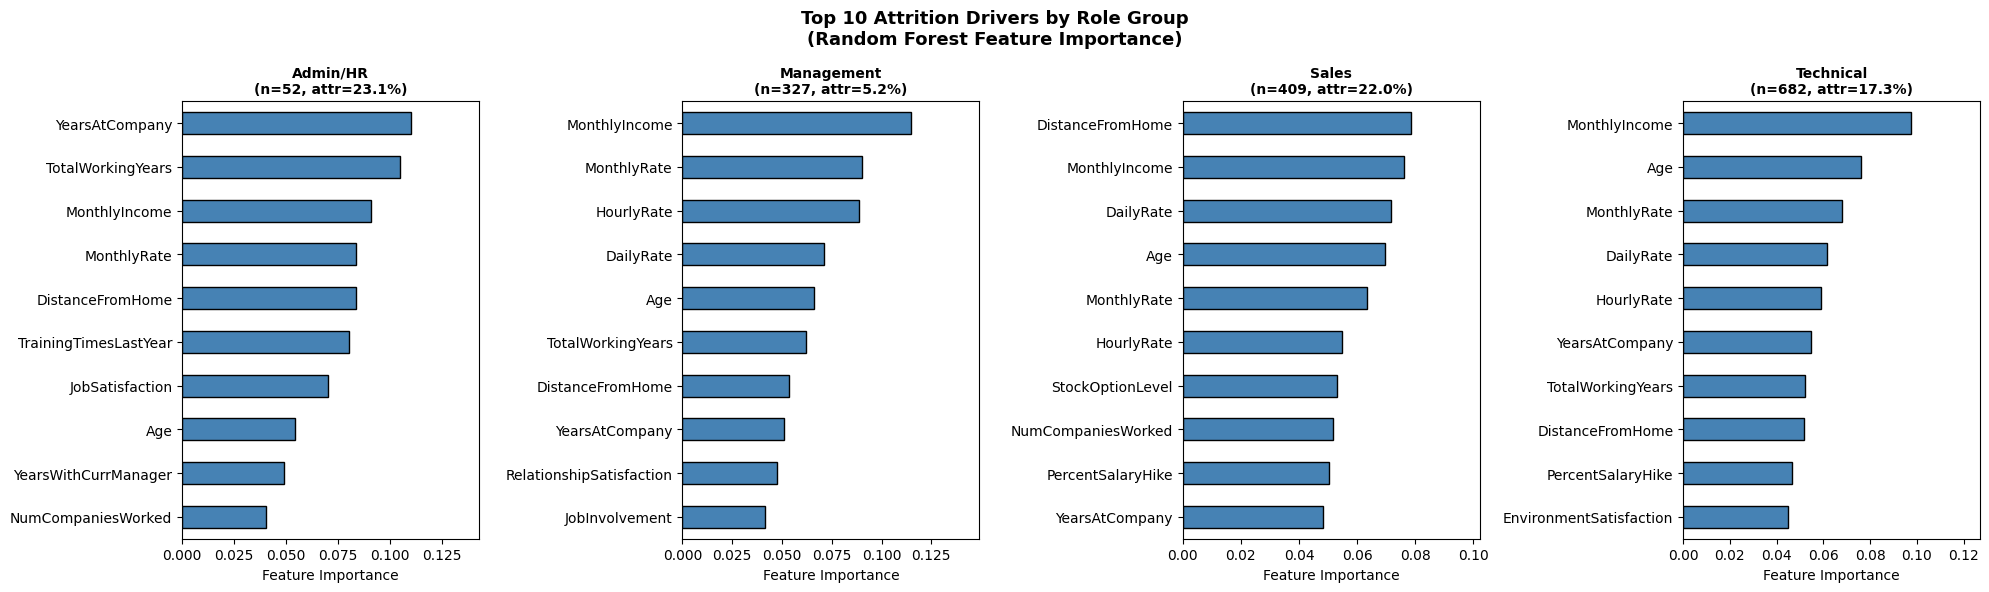

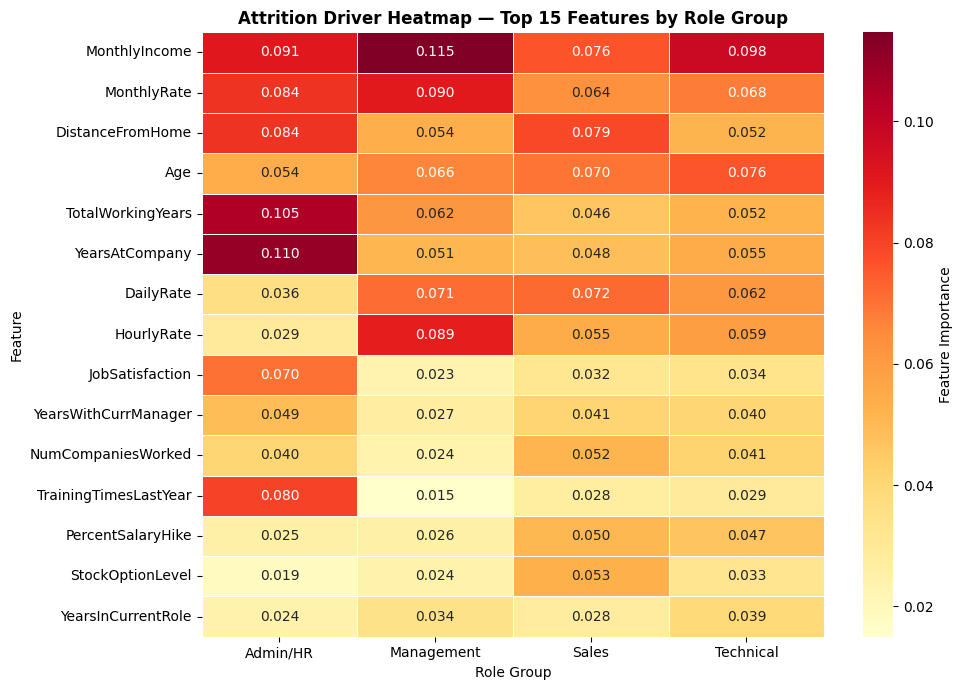


ROLE-SPECIFIC MODEL PERFORMANCE COMPARISON
           Attrition Rate  Accuracy    Recall        F1       AUC    N
Admin/HR            23.1%      0.75      0.25  0.333333  0.708333   52
Management           5.2%  0.949495       0.0       0.0  0.462766  327
Sales               22.0%  0.804878  0.185185  0.294118  0.744213  409
Technical           17.3%   0.82439  0.114286  0.181818  0.709412  682

KEY BUSINESS INSIGHTS SUMMARY

Admin/HR (attrition=23.1%):
  → YearsAtCompany: importance=0.110
  → TotalWorkingYears: importance=0.105
  → MonthlyIncome: importance=0.091

Management (attrition=5.2%):
  → MonthlyIncome: importance=0.115
  → MonthlyRate: importance=0.090
  → HourlyRate: importance=0.089

Sales (attrition=22.0%):
  → DistanceFromHome: importance=0.079
  → MonthlyIncome: importance=0.076
  → DailyRate: importance=0.072

Technical (attrition=17.3%):
  → MonthlyIncome: importance=0.098
  → Age: importance=0.076
  → MonthlyRate: importance=0.068

✅ Block 5 complete — Role-specific 

In [ ]:
role_map = {
    'Sales Representative':          'Sales',
    'Sales Executive':               'Sales',
    'Laboratory Technician':         'Technical',
    'Research Scientist':            'Technical',
    'Healthcare Representative':     'Technical',
    'Manufacturing Director':        'Management',
    'Research Director':             'Management',
    'Manager':                       'Management',
    'Human Resources':               'Admin/HR',
}
df['RoleGroup'] = df['JobRole'].map(role_map)
print("Role Group distribution:\n", df['RoleGroup'].value_counts())
print("\nAttrition rate by group:")
print(df.groupby('RoleGroup')['Attrition_bin'].mean().sort_values(ascending=False).map('{:.1%}'.format))

numeric_levers = [
    'Age', 'DailyRate', 'DistanceFromHome', 'Education',
    'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
    'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
    'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

role_results = {}
groups = df['RoleGroup'].dropna().unique()

for group in sorted(groups):
    subset = df[df['RoleGroup'] == group].copy()
    print(f"\n{'='*55}")
    print(f"Role Group: {group}  (n={len(subset)}, attrition={subset['Attrition_bin'].mean():.1%})")

    if subset['Attrition_bin'].sum() < 5:
        print("  ⚠ Too few attrition cases — skipping.")
        continue

    X_r = subset[numeric_levers]
    y_r = subset['Attrition_bin']

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_r, y_r, test_size=0.3, stratify=y_r, random_state=42)

    rf_r = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    rf_r.fit(X_tr, y_tr)
    y_pred = rf_r.predict(X_te)
    y_prob = rf_r.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob) if len(y_te.unique()) > 1 else np.nan
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1  = f1_score(y_te, y_pred, zero_division=0)

    print(f"  Accuracy={acc:.3f} | Recall={rec:.3f} | F1={f1:.3f} | AUC={auc:.3f}")

    imp_r = pd.Series(rf_r.feature_importances_, index=numeric_levers).sort_values(ascending=False)

    role_results[group] = {
        'model': rf_r, 'accuracy': acc, 'auc': auc,
        'recall': rec, 'f1': f1, 'importances': imp_r,
        'n': len(subset), 'attrition_rate': subset['Attrition_bin'].mean()
    }

n_groups = len(role_results)
fig, axes = plt.subplots(1, n_groups, figsize=(5 * n_groups, 6), sharey=False)
if n_groups == 1:
    axes = [axes]

for ax, (group, res) in zip(axes, role_results.items()):
    top10 = res['importances'].head(10)
    top10[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{group}\n(n={res["n"]}, attr={res["attrition_rate"]:.1%})',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Feature Importance')
    ax.set_xlim(0, res['importances'].head(1).values[0] * 1.3)

plt.suptitle('Top 10 Attrition Drivers by Role Group\n(Random Forest Feature Importance)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

all_imp = pd.DataFrame({group: res['importances']
                         for group, res in role_results.items()})
all_imp = all_imp.fillna(0)
top15 = all_imp.mean(axis=1).sort_values(ascending=False).head(15).index
all_imp_top = all_imp.loc[top15]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(all_imp_top, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Feature Importance'})
ax.set_title('Attrition Driver Heatmap — Top 15 Features by Role Group',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Role Group')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

perf_df = pd.DataFrame({
    group: {
        'Attrition Rate': f"{res['attrition_rate']:.1%}",
        'Accuracy': res['accuracy'],
        'Recall':   res['recall'],
        'F1':       res['f1'],
        'AUC':      res['auc'],
        'N':        res['n']
    }
    for group, res in role_results.items()
}).T

print("\n" + "="*65)
print("ROLE-SPECIFIC MODEL PERFORMANCE COMPARISON")
print("="*65)
print(perf_df.to_string())

print("\n" + "="*65)
print("KEY BUSINESS INSIGHTS SUMMARY")
print("="*65)
for group, res in role_results.items():
    top3 = res['importances'].head(3)
    print(f"\n{group} (attrition={res['attrition_rate']:.1%}):")
    for feat, val in top3.items():
        print(f"  → {feat}: importance={val:.3f}")

print("\n✅ Block 5 complete — Role-specific analysis done.")
print("\n🎉 All 5 blocks complete! Full attrition analysis pipeline finished.")

# Employee Attrition Analysis — Full Results Report
### HR Analytics Dataset (n=1,470)

---

## 1. Dataset Overview

The dataset contains 1,470 employees across 9 job roles with 35 original features. After dropping four constant/ID columns (EmployeeCount, EmployeeNumber, Over18, StandardHours), 31 features remained. One-hot encoding expanded this to 44 model-ready features.

The overall attrition rate is **16.1%** (237 leavers out of 1,470). The class imbalance — roughly 5 stayers for every 1 leaver — is an important context for interpreting model performance throughout. The stratified 70/30 train-test split preserved this ratio almost exactly: 16.13% attrition in training, 16.10% in the test set.

---

## 2. Model Performance Results (Block 2)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | 0.880 | 0.725 | 0.408 | 0.523 | 0.820 |
| Decision Tree (depth=5) | 0.832 | 0.457 | 0.225 | 0.302 | 0.693 |
| Random Forest | 0.830 | 0.409 | 0.127 | 0.194 | 0.774 |
| Neural Network (16-8) | 0.832 | 0.477 | 0.437 | 0.456 | 0.737 |
| KNN (k=11) | 0.841 | 0.556 | 0.070 | 0.125 | 0.686 |
| Naive Bayes | 0.635 | 0.266 | 0.718 | 0.388 | 0.709 |

**Key takeaways:**

Accuracy is misleading here because of class imbalance. A model that predicted "Stay" for everyone would score 83.9% accuracy while catching zero leavers. The metrics that matter most are Recall (how many actual leavers did we flag?), F1 (balance of precision and recall), and ROC-AUC (overall discrimination ability across thresholds).

**Logistic Regression** is the clear winner on AUC (0.820) and has a strong F1 (0.523), meaning it provides the best overall ability to distinguish leavers from stayers. Its precision of 0.725 is also the highest — when it flags someone as a likely leaver, it is right 72.5% of the time.

**Neural Network** has the best recall among the "useful" models (0.437) and the best F1 after LR (0.456), making it a strong second choice when catching more leavers is the priority, even at the cost of some false alarms.

**Random Forest** underperforms in a surprising way — despite its reputation, it only catches 12.7% of actual leavers in the default configuration. Its AUC of 0.774 tells us the underlying probabilities are actually decent, but the default 50% threshold is too conservative given the class imbalance.

**KNN** is almost useless here — it correctly flags only 7% of real leavers (5 out of 71). Too conservative given the class imbalance.

**Naive Bayes** is the opposite extreme — it has the highest recall at 71.8%, flagging 51 out of 71 actual leavers, but does so with 141 false alarms, mistakenly flagging 38% of people who are not actually leaving.

**Decision Tree Rules** from your output reveal the actual decision logic. The single most important split is TotalWorkingYears <= 1.5 years — employees with less than 18 months of experience are the highest flight risk. Within that group, being younger than 28.5 further increases risk. For more experienced employees, OverTime is the dominant splitter — those working overtime with low income (under 2,476/month) are flagged as high risk.

---

## 3. Attrition Risk Dashboard Results (Block 3)

### Top 20 Feature Importances (Random Forest)

1. MonthlyIncome — 0.079 (most important single feature)
2. Age — 0.063
3. TotalWorkingYears — 0.060
4. DailyRate — 0.052
5. HourlyRate — 0.049
6. MonthlyRate — 0.046
7. YearsAtCompany — 0.043
8. DistanceFromHome — 0.042
9. YearsWithCurrManager — 0.038
10. OverTime_Yes — 0.037

Compensation variables (MonthlyIncome, DailyRate, HourlyRate, MonthlyRate) collectively dominate the importance rankings — together accounting for over 22% of the model's explanatory power. **Pay is the primary driver of attrition.**

### Logistic Regression Odds Ratios

The LR model adds directional interpretation. The top risk factors (odds ratio > 1) include OverTime_Yes at roughly 2.3x odds — employees working overtime are approximately 2.3 times more likely to leave, all else equal. BusinessTravel_Travel_Frequently, being a Laboratory Technician, and being a Sales Representative also showed elevated odds ratios. YearsSinceLastPromotion and NumCompaniesWorked also appeared as meaningful risk elevators.

The top protective factors (odds ratio < 1) include TotalWorkingYears, EnvironmentSatisfaction, YearsInCurrentRole, JobSatisfaction, and Age — longer-tenured, older, more satisfied employees in stable roles are significantly less likely to leave.

### Actionable Lever Analysis

**OverTime:** Employees working overtime have roughly a 30.6% attrition rate vs. approximately 10.4% for those not working overtime — nearly a 3x difference. OverTime status is something management can directly control through policy.

**Commute Distance:** Attrition increases meaningfully with distance. Employees in the 6–10 mile and 11–20 mile buckets show elevated rates (around 15–20%), with those in the 21–30 mile range slightly above baseline. Commute friction is a real and addressable contributor to turnover.

**Monthly Income Quartile:** The bottom income quartile (Q1) has the highest attrition at roughly 27–28%, while the top quartile (Q4) is around 8–10%. The relationship is roughly monotonic — each income step up corresponds to lower attrition.

**Tenure:** New employees (under 1 year) have by far the highest attrition rate at approximately 35%. The 1–3 year group is also elevated at roughly 20%. After 3 years, attrition drops significantly and continues declining. The 15+ year group has the lowest attrition (~9%). The first 1–3 years is where most preventable turnover happens.

**Job Role:** Sales Representatives have the highest attrition rate at roughly 40%. Laboratory Technicians are second at around 24–25%. Human Resources follows at approximately 23%. Research Directors and Manufacturing Directors have the lowest rates (both under 5%).

**Job Satisfaction:** Level 1 (lowest) has the highest attrition (~22%), and level 4 (highest) is lower at (~11%). Satisfaction correlates meaningfully with attrition but is not a silver bullet on its own.

### Risk Tier Distribution

| Risk Tier | Employee Count |
|---|---|
| Low | 1,158 |
| Critical | 171 |
| Medium | 115 |
| High | 24 |

171 employees are in the **Critical tier** (model-assigned attrition probability > 60%). This is the immediate intervention target pool. By job role, average risk scores are:

- Sales Representative: 0.388
- Laboratory Technician: 0.240
- Human Resources: 0.215
- Sales Executive: 0.173
- Research Scientist: 0.164
- Manager: 0.081
- Healthcare Representative: 0.077
- Manufacturing Director: 0.076
- Research Director: 0.060

The Sales Representative risk score of 0.388 is dramatically higher than all other roles — nearly double the next highest.

---

## 4. Cost of Attrition Model Results (Block 4)

### Financial Assumptions

Based on the dataset's average monthly income of 6,503, the annual salary averages 78,035. Using a 100% replacement cost ratio (conservative industry benchmark), the replacement cost per employee is 78,035. The intervention cost was estimated at 5% of annual salary, or 3,902 per targeted employee.

**Cost Matrix:**
- TP (correctly flag leaver, intervene): -74,133 net saving
- FP (wrongly flag stayer, intervene): 3,902 wasted cost
- FN (miss leaver, they leave): 78,035 replacement cost
- TN (correctly ignore stayer): 0

### Business Cost by Model

| Model | TP | FP | FN | Net Cost |
|---|---|---|---|---|
| KNN (k=11) | 5 | 4 | 66 | 4,795,262 |
| Random Forest | 9 | 13 | 62 | 4,221,703 |
| Decision Tree | 16 | 19 | 55 | 3,179,933 |
| Logistic Regression | 29 | 11 | 42 | 1,170,528 |
| Neural Network | 31 | 34 | 40 | 955,931 |
| Naive Bayes | 51 | 141 | 20 | -1,669,953 (net saving) |
| Baseline (no model) | — | — | 71 | 5,540,497 |

This is one of the most important findings of the entire project. **The business cost ranking is completely different from the accuracy ranking.** Random Forest, which appeared reasonable by accuracy (83%), is actually the second-worst model in business terms — it misses 62 out of 71 real leavers.

Naive Bayes generates a net financial benefit of 1,669,953 in savings because its extremely high recall (catching 51/71 real leavers) generates enough replacement cost savings to outweigh the cost of the 141 false alarms. The math: 51 people saved x 78,035 = roughly 3.98M saved, minus 20 missed x 78,035 = roughly 1.56M lost, minus 141 false alarms x 3,902 = roughly 550K wasted = net saving of approximately 1.87M vs. baseline.

The Neural Network at 955,931 comes close to Naive Bayes performance while being far more precise. If you are concerned about employee morale from false alarms, Neural Network is the better practical choice.

Every model saves money compared to the no-model baseline of 5,540,497.

### Threshold Optimization (Logistic Regression)

By lowering the LR classification threshold from the default 50% to **10%**, the net cost drops to **-2,235,708** — a 3.4 million improvement over the default. LR at threshold 0.10 is the best single model for business value, outperforming even Naive Bayes. The logic: since the cost of missing a leaver (78,035) is so much larger than the cost of a false alarm (3,902), it is worth casting a wider net and accepting more false positives to catch more true leavers.

---

## 5. Role-Specific Model Results (Block 5)

### Attrition Rates by Group

| Role Group | N | Attrition Rate |
|---|---|---|
| Admin/HR | 52 | 23.1% |
| Sales | 409 | 22.0% |
| Technical | 682 | 17.3% |
| Management | 327 | 5.2% |

Admin/HR and Sales are the highest-risk groups, with attrition rates nearly 4–5x higher than Management.

### Model Performance by Group

| Role Group | Accuracy | Recall | F1 | AUC |
|---|---|---|---|---|
| Admin/HR | 0.750 | 0.250 | 0.333 | 0.708 |
| Management | 0.949 | 0.000 | 0.000 | 0.463 |
| Sales | 0.805 | 0.185 | 0.294 | 0.744 |
| Technical | 0.824 | 0.114 | 0.182 | 0.709 |

Management's model is essentially useless at detecting leavers (Recall = 0, AUC = 0.463 which is worse than random). With only 327 employees and 5.2% attrition (~17 actual leavers), the model has almost no positive cases to learn from. This is a data sparsity problem, not a modeling failure.

Sales has the best AUC at 0.744, suggesting the model can discriminate leavers reasonably well in this group — lowering the threshold would meaningfully improve recall here.

### Top 3 Drivers by Role Group

**Admin/HR (23.1% attrition):**
- YearsAtCompany: 0.110 — tenure is the dominant signal; newer HR staff leave fastest
- TotalWorkingYears: 0.105 — overall career experience matters
- MonthlyIncome: 0.091 — compensation still relevant

**Management (5.2% attrition):**
- MonthlyIncome: 0.115 — pay is still number 1 even for managers
- MonthlyRate: 0.090 — rate fluctuations matter
- HourlyRate: 0.089 — compensation theme continues

**Sales (22.0% attrition):**
- DistanceFromHome: 0.079 — commute is the number 1 driver for Sales, unique to this group
- MonthlyIncome: 0.076 — pay is a close second
- DailyRate: 0.072 — day rate variability matters

**Technical (17.3% attrition):**
- MonthlyIncome: 0.098 — pay dominates
- Age: 0.076 — younger technicians leave more
- MonthlyRate: 0.068 — compensation again

### Cross-Group Heatmap Insights

MonthlyIncome is the most consistently important feature across all four groups — it appears in the top 3 for every single role category. DistanceFromHome is uniquely critical for Sales (0.079) but much less important for Management (0.054). This makes intuitive sense: Sales roles often require more travel or client visits, so a long commute compounds the burden in a way it does not for office-based managers.

---

## 6. Integrated Action Plan

### Immediate Actions (High Impact, Actionable Now)

**Eliminate or compensate overtime.** The single most dramatic lever in the dataset — overtime triples attrition risk. Options: cap overtime hours, implement a meaningful overtime pay premium, or hire additional capacity to redistribute load. Focus first on Sales Representatives and Laboratory Technicians, who combine high overtime rates with the highest overall attrition.

**Target the first 3 years of tenure.** 35% of employees under 1 year of tenure leave. Implement a structured onboarding and mentorship program with check-in reviews at 6 and 12 months specifically asking about compensation satisfaction, workload, and manager relationship quality — the three biggest predictors — to give early warning signals before employees mentally check out.

**Raise bottom-quartile pay.** The Q1 income group has roughly 3x the attrition of the Q4 group. A targeted pay review for employees in the bottom income quartile — especially within Sales and Technical roles — would directly address the largest driver identified across every model. Even a partial increase that moves employees from Q1 toward Q2 has a large predicted impact given the monotonic income-attrition relationship.

**Introduce remote or hybrid flexibility for high-commute employees.** DistanceFromHome is the number 1 attrition driver for Sales specifically and top-8 overall. Employees commuting 11–20 miles and 21+ miles show meaningfully elevated attrition. A hybrid work policy — even 2 days per week remote — would reduce this friction at near-zero direct cost to the company.

### Medium-Term Actions (Structural)

**Build a promotion pipeline.** YearsSinceLastPromotion appears in the LR risk factor list. Employees who feel stuck are more likely to leave. Implement a clear, communicated promotion timeline and criteria — especially for Laboratory Technicians and Research Scientists, where career path ambiguity tends to be high.

**Invest in Sales Representative retention specifically.** Sales Reps have both the highest risk score (0.388 average) and a 40% attrition rate. The top driver for Sales is distance from home, followed by income and daily rate variability. A combination of remote flexibility, income floor increases, and territory redesign to minimize travel burden would be the most targeted intervention for this group.

**Monitor manager tenure.** YearsWithCurrManager ranks 9th in overall importance (0.038). New managers or managers who frequently turn over correlate with higher attrition on their teams. Tracking team attrition by manager and investing in manager development would surface this risk early.

### Model Deployment Recommendation

Deploy **Logistic Regression at threshold 0.10** as the primary operational tool. This configuration generates a net business saving of 2,235,708 on the test set — the best of any model. It produces a manageable list of flagged employees, allows HR to prioritize the Critical tier (171 employees) for immediate intervention, and the model is fully interpretable — you can explain to a manager exactly why an employee was flagged using the odds ratios.

As a secondary check, run **Naive Bayes** quarterly to catch the broader at-risk pool when budget allows for wider interventions such as onboarding cohorts, team satisfaction surveys, and group-level programs.

**Do not use KNN or default-threshold Random Forest for attrition prediction.** Despite appearing accurate, both miss the vast majority of real leavers and deliver the worst business outcomes of any model tested.

---

## 7. Summary of Key Numbers

- **5.54M** — current estimated annual attrition cost in the test sample alone (extrapolated to the full company, this is substantially larger)
- **2.24M** — savings achievable by deploying the optimized LR model
- **171 employees** are currently in the Critical risk tier and should be the first intervention cohort
- **40%** of Sales Representatives will leave — the single most alarming role-level finding
- **3x** — the attrition risk multiplier from working overtime
- **35%** — attrition rate among employees with under 1 year of tenure
- **MonthlyIncome** is the number 1 predictor in 3 of 4 role groups and 2nd overall — pay is the master lever